> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** the generic data-manipulation toolkit, taught before it's needed for hydrography/sound-speed/combining: slicing and subsetting a time series, averaging/resampling, interpolating, and the mechanics of `xr.corr` on two already-available variables (e.g. TEMP vs PSAL) -- SVEL doesn't exist yet at this point in the series, so the correlation example here should use raw/QC'd variables, not sound speed.

**To do:** everything -- this notebook doesn't exist yet beyond this structure.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Slicing, averaging, interpolating, and correlating

- Slicing and subsetting a time series
- Averaging and resampling
- Interpolating
- Correlating two time series

In [30]:
import xarray as xr
from kval.data import moored
from matplotlib import pyplot as plt
%matplotlib widget

In [2]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc', decode_cf=True)

### Slicing and subsetting

Xarray is built around the concept of *labelled coordinates* - i.e. each variable is associated with a particular set of dimensions. 

This makes it very easy to ..

#### Select by coorindate value (in this case - a particular date)

In [3]:
ds_feb_01 = ds.sel(TIME = '2022-02-01 21:00', method = 'nearest')

In [4]:
ds_feb_01

<xarray.Dataset> Size: 80B
Dimensions:    ()
Coordinates:
    TIME       datetime64[ns] 8B 2022-02-01T20:58:41.487929856
Data variables:
    CNDC       float64 8B ...
    TEMP       float64 8B ...
    PRES       float64 8B ...
    DEPTH      float64 8B ...
    PSAL       float64 8B ...
    SVEL       float64 8B ...
    SPCNDC     float64 8B ...
    LATITUDE   int64 8B ...
    LONGITUDE  int64 8B ...
Attributes:
    history:                   2021-11-08 - 2022-04-24: Data collection.\n202...
    date_created:              2026-09-20T23:31:31Z
    instrument_model:          RBRconcerto
    instrument_serial_number:  60595
    source_file:               AT800_21_22_CONCERTO_60595_99m.rsk
    time_coverage_resolution:  P0000-00-00T00:10:00
    sampling_details:          One average of 15 samples collected at 2 sec i...

#### Select by coorindate value (in this case - a particular date)

For this, we use the function `isel` (select buy index)

In [5]:
ds_ind1000 = ds.isel(TIME = 1000)

### Averaging and resampling

- 

In [13]:
ds_avgd = moored.time_average(ds, '12h')

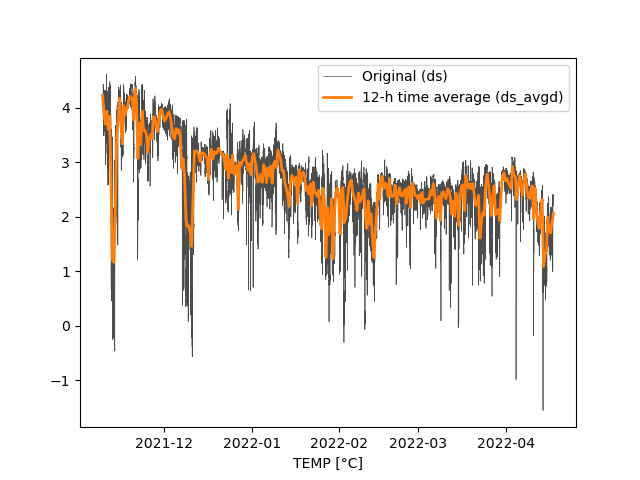

In [27]:
fig, ax = plt.subplots()
ax.plot(ds.TIME, ds.TEMP, label = 'Original (ds)', color = 'k', alpha = 0.7, lw = 0.5)
ax.plot(ds_avgd.TIME, ds_avgd.TEMP, label = '12-h time average (ds_avgd)', color = 'tab:orange', lw = 2)
ax.set_xlabel('TEMP [°C]')
ax.legend()


In [5]:
#### xaray resmapling

### Interpolating

- 

In [ ]:
##### Interpolate

### Correlating two time series
For example, lets say we are interested in the correclation between `TEMP` and `PSAL` om our dataset: 

In [40]:
timeseries_1 = ds.TEMP
timeseries_2 = ds.PSAL

In [41]:
pcorr = xr.corr(timeseries_1, timeseries_2)
print(f'p = {pcorr:.3f}')

p = 0.793


At `p = 0.793`, we can se that there is a relatively positive correlations between the two variables.

For more complex statristical analysis, look into the `stats` submodule of the [Scipy](https://scipy.org/) package - it is widely used for statistics, bmachine learning.  